# 📊 Análisis de Estadísticas de Deuda Internacional / International Debt Statistics Analysis

Análisis exploratorio de datos de deuda externa de distintos países del mundo (dataset estilo *World Bank*),
usando **Python (pandas)** y **SQL (SQLite)**.

**Objetivo:** identificar qué países presentan mayor endeudamiento, cómo se compone esa deuda
(bilateral vs. multilateral, principal vs. intereses) y qué tan "cargados" están algunos países
en términos de servicio de deuda respecto a lo que reciben en desembolsos.

---

 **English**

Exploratory analysis of external debt data for different countries around the world (World Bank–style
dataset), using **Python (pandas)** and **SQL (SQLite)**.

**Objective:** identify which countries carry the highest debt burden, how that debt is composed
(bilateral vs. multilateral, principal vs. interest), and how "loaded" some countries are in terms
of debt service relative to the disbursements they receive.

In [1]:
%pip install pandas matplotlib seaborn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.float_format", lambda x: f"{x:,.0f}")

## 1. Carga y exploración inicial de los datos / 1. Initial Data Loading & Exploration

In [3]:
df = pd.read_csv("data/international_debt.csv")
df.head()

,country_name,country_code,indicator_name,indicator_code,debt
0,Afghanistan,AFG,"Disbursements on external debt, long-term (DIS...",DT.DIS.DLXF.CD,"72,894,454"
1,Afghanistan,AFG,"Interest payments on external debt, long-term ...",DT.INT.DLXF.CD,"53,239,440"
2,Afghanistan,AFG,"PPG, bilateral (AMT, current US$)",DT.AMT.BLAT.CD,"61,739,337"
3,Afghanistan,AFG,"PPG, bilateral (DIS, current US$)",DT.DIS.BLAT.CD,"49,114,729"
4,Afghanistan,AFG,"PPG, bilateral (INT, current US$)",DT.INT.BLAT.CD,"39,903,620"


In [4]:
print("Filas x columnas:", df.shape)
print("\nValores nulos por columna:")
print(df.isnull().sum())
print(f"\nPaíses / agrupaciones únicas: {df['country_name'].nunique()}")
print(f"Indicadores únicos: {df['indicator_name'].nunique()}")

Filas x columnas: (2357, 5)

Valores nulos por columna:
country_name      0
country_code      0
indicator_name    0
indicator_code    0
debt              0
dtype: int64

Países / agrupaciones únicas: 124
Indicadores únicos: 25


## 2. Conexión a base de datos SQL / 2. Connecting to the SQL Database

Igual que en la versión original: cargamos el DataFrame a una base SQLite para poder
resolver las preguntas de negocio con consultas SQL.

---

 Same as in the original version: we load the DataFrame into a SQLite database so we can
answer the business questions using SQL queries.

In [5]:
conn = sqlite3.connect("data/international_debt.db")
df.to_sql("international_debt", conn, if_exists="replace", index=False)

pd.read_sql("SELECT * FROM international_debt LIMIT 5", conn)

,country_name,country_code,indicator_name,indicator_code,debt
0,Afghanistan,AFG,"Disbursements on external debt, long-term (DIS...",DT.DIS.DLXF.CD,"72,894,454"
1,Afghanistan,AFG,"Interest payments on external debt, long-term ...",DT.INT.DLXF.CD,"53,239,440"
2,Afghanistan,AFG,"PPG, bilateral (AMT, current US$)",DT.AMT.BLAT.CD,"61,739,337"
3,Afghanistan,AFG,"PPG, bilateral (DIS, current US$)",DT.DIS.BLAT.CD,"49,114,729"
4,Afghanistan,AFG,"PPG, bilateral (INT, current US$)",DT.INT.BLAT.CD,"39,903,620"


## 3. Limpieza: separar países individuales de agregados regionales / 3. Cleaning: Separating Individual Countries from Regional Aggregates

El dataset del Banco Mundial mezcla **países individuales** con **agrupaciones/clasificaciones
regionales** (por ejemplo *"South Asia"* o *"Least developed countries"*). Si no se separan,
esas agrupaciones distorsionan los rankings "por país", porque en realidad son la suma de
varios países a la vez. Este es el principal problema que tenía la versión original del análisis.

---

 The World Bank dataset mixes **individual countries** with **regional groupings/classifications**
(e.g. *"South Asia"* or *"Least developed countries"*). If they aren't separated, these groupings
distort the "per-country" rankings, since they're actually the sum of several countries at once.
This was the main issue with the original version of the analysis.

In [6]:
agregados_regionales = [
    "South Asia",
    "Least developed countries: UN classification",
    "IDA only",
]

df["es_agregado_regional"] = df["country_name"].isin(agregados_regionales)

# Guardamos también en la base de datos, para poder filtrar con SQL / We also save it back to the DB so we can filter it with SQL
df.to_sql("international_debt", conn, if_exists="replace", index=False)

print(f"Registros de agregados regionales: {df['es_agregado_regional'].sum()}")
print(f"Registros de países individuales: {(~df['es_agregado_regional']).sum()}")
df[df["es_agregado_regional"]][["country_name", "country_code"]].drop_duplicates()

Registros de agregados regionales: 74
Registros de países individuales: 2283


,country_name,country_code
986,IDA only,IDX
1221,Least developed countries: UN classification,LDC
1932,South Asia,SAS


## 4. Preguntas de negocio (versión original, ahora con datos limpios) / 4. Business Questions (Original Version, Now with Clean Data)

### 4.1 ¿Qué países tienen la mayor deuda total registrada? / 4.1 Which countries have the highest total recorded debt?

A diferencia de la primera versión, aquí **excluimos los agregados regionales** para que el
ranking refleje países reales y sea directamente comparable.

---

 Unlike the first version, here we **exclude regional aggregates** so the ranking reflects
real countries and is directly comparable.

In [7]:
top_paises = pd.read_sql('''
    SELECT country_name, SUM(debt) AS total_debt
    FROM international_debt
    WHERE es_agregado_regional = 0
    GROUP BY country_name
    ORDER BY total_debt DESC
    LIMIT 10
''', conn)

top_paises

,country_name,total_debt
0,China,"285,793,494,734"
1,Brazil,"280,623,966,141"
2,Russian Federation,"191,289,057,259"
3,Turkey,"151,125,758,035"
4,India,"133,627,060,958"
5,Mexico,"124,596,786,217"
6,Indonesia,"113,435,696,694"
7,Cameroon,"86,491,206,347"
8,Angola,"71,368,842,500"
9,Kazakhstan,"70,159,942,694"


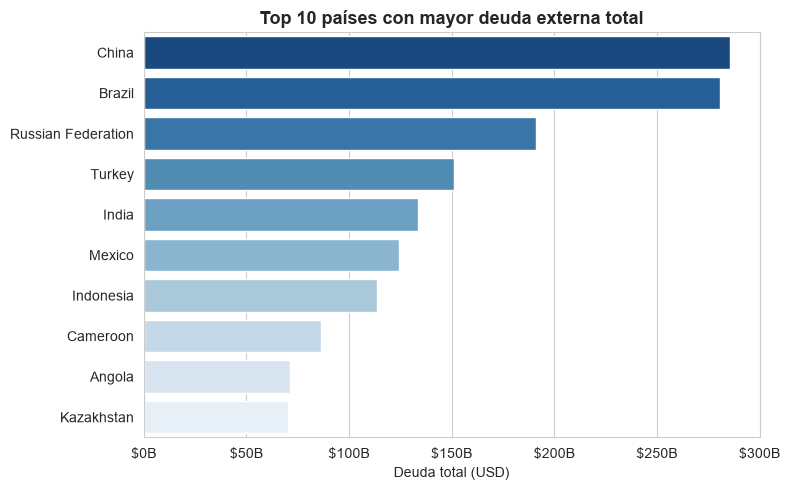

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=top_paises, y="country_name", x="total_debt", hue="country_name", palette="Blues_r", legend=False, ax=ax)
ax.set_title("Top 10 países con mayor deuda externa total", fontsize=13, fontweight="bold")
ax.set_xlabel("Deuda total (USD)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e9:,.0f}B"))
plt.tight_layout()
plt.show()

**Lectura:** China y Brasil concentran la mayor deuda externa acumulada del dataset,
seguidos de Rusia, Turquía, India, México e Indonesia. Al quitar los agregados regionales,
el ranking ahora compara países entre sí de forma justa.

 **Takeaway:** China and Brazil hold the largest accumulated external debt in the dataset,
followed by Russia, Turkey, India, Mexico, and Indonesia. After removing the regional
aggregates, the ranking now compares countries fairly against one another.

### 4.2 ¿Cuál es el promedio de deuda por tipo de indicador? / 4.2 What is the average debt by indicator type?

In [9]:
avg_indicador = pd.read_sql('''
    SELECT indicator_name, AVG(debt) AS avg_debt
    FROM international_debt
    WHERE es_agregado_regional = 0
    GROUP BY indicator_name
    ORDER BY avg_debt DESC
    LIMIT 10
''', conn)

avg_indicador

,indicator_name,avg_debt
0,"Principal repayments on external debt, long-te...","5,270,802,210"
1,"Principal repayments on external debt, private...","4,911,086,825"
2,"PPG, private creditors (AMT, current US$)","1,676,771,166"
3,"Interest payments on external debt, long-term ...","1,434,487,195"
4,"Disbursements on external debt, long-term (DIS...","1,339,190,827"
5,"PPG, official creditors (DIS, current US$)","1,172,032,575"
6,"Interest payments on external debt, private no...","1,113,929,715"
7,"PPG, bonds (AMT, current US$)","1,034,612,635"
8,"PPG, official creditors (AMT, current US$)","869,679,404"
9,"PPG, bonds (INT, current US$)","788,446,544"


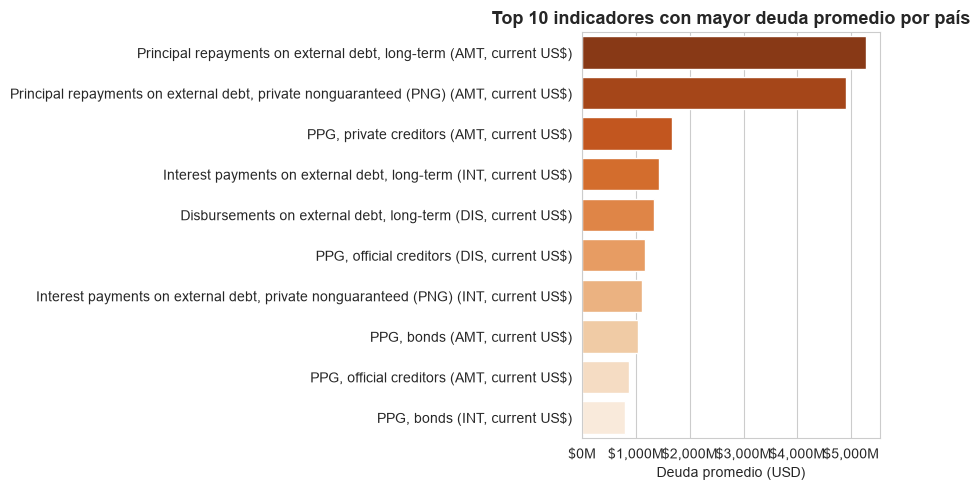

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=avg_indicador, y="indicator_name", x="avg_debt", hue="indicator_name", palette="Oranges_r", legend=False, ax=ax)
ax.set_title("Top 10 indicadores con mayor deuda promedio por país", fontsize=13, fontweight="bold")
ax.set_xlabel("Deuda promedio (USD)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:,.0f}M"))
plt.tight_layout()
plt.show()

**Lectura:** los indicadores de mayor magnitud promedio corresponden a los totales de largo
plazo (desembolsos, principal e intereses) y a la deuda con acreedores oficiales/bilaterales,
lo cual tiene sentido: son las categorías "sombrilla" que agregan varias subcategorías.

**Takeaway:** the indicators with the largest average magnitude correspond to long-term
totals (disbursements, principal, and interest) and to debt owed to official/bilateral
creditors, which makes sense: these are the "umbrella" categories that aggregate several
subcategories.

### 4.3 ¿Qué país tiene la mayor deuda para cada tipo de indicador? / 4.3 Which country has the highest debt for each indicator type?

In [11]:
max_por_indicador = pd.read_sql('''
    SELECT d.indicator_name, d.country_name, d.debt AS max_debt
    FROM international_debt d
    INNER JOIN (
        SELECT indicator_name, MAX(debt) AS max_debt
        FROM international_debt
        WHERE es_agregado_regional = 0
        GROUP BY indicator_name
    ) m ON d.indicator_name = m.indicator_name AND d.debt = m.max_debt
    WHERE d.es_agregado_regional = 0
    ORDER BY max_debt DESC
''', conn)

max_por_indicador

,indicator_name,country_name,max_debt
0,"Principal repayments on external debt, long-te...",China,"96,218,620,836"
1,"Principal repayments on external debt, private...",China,"72,392,986,214"
2,"PPG, private creditors (AMT, current US$)",Brazil,"43,598,697,499"
3,"PPG, other private creditors (AMT, current US$)",Brazil,"35,119,003,750"
4,"PPG, commercial banks (AMT, current US$)",Russian Federation,"22,077,398,848"
5,"Interest payments on external debt, long-term ...",Mexico,"19,267,966,623"
6,"Disbursements on external debt, long-term (DIS...",Cameroon,"18,186,662,060"
7,"PPG, official creditors (DIS, current US$)",Cameroon,"17,940,581,036"
8,"PPG, bonds (AMT, current US$)",Mexico,"17,109,552,312"
9,"PPG, bilateral (DIS, current US$)",Cameroon,"17,090,544,248"


**Lectura:** China vuelve a aparecer como líder en la mayoría de las categorías de deuda,
lo cual es consistente con el hallazgo de 4.1: es, en términos absolutos, el país con mayor
volumen de endeudamiento externo en este dataset.

 **Takeaway:** China shows up again as the leader in most debt categories, which is
consistent with the 4.1 finding: in absolute terms, it's the country with the highest volume
of external debt in this dataset.

## 5. Preguntas de negocio más profundas (mejoras sobre el análisis original) / 5. Deeper Business Questions (Improvements over the Original Analysis)

### 5.1 Participación (%) de los principales países sobre la deuda global / 5.1 Share (%) of Top Countries in Global Debt

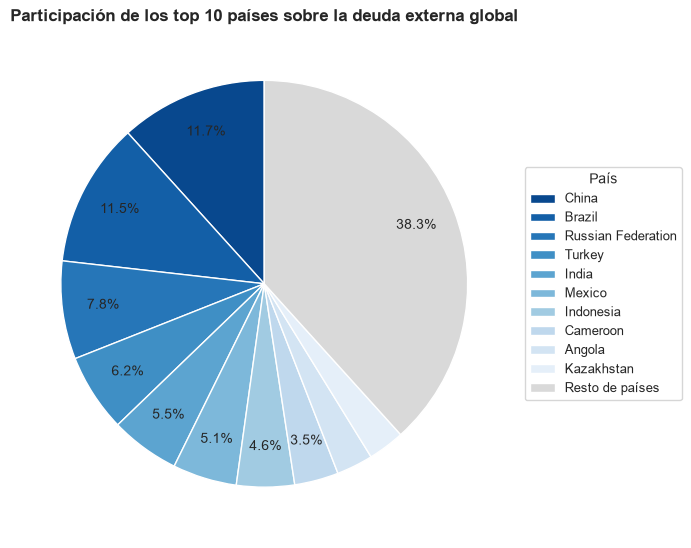

,country_name,total_debt,participacion_%
0,China,"285,793,494,734",12
1,Brazil,"280,623,966,141",12
2,Russian Federation,"191,289,057,259",8
3,Turkey,"151,125,758,035",6
4,India,"133,627,060,958",6
5,Mexico,"124,596,786,217",5
6,Indonesia,"113,435,696,694",5
7,Cameroon,"86,491,206,347",4
8,Angola,"71,368,842,500",3
9,Kazakhstan,"70,159,942,694",3


In [12]:
deuda_total_global = df.loc[~df["es_agregado_regional"], "debt"].sum()

top10 = top_paises.copy()
top10["participacion_%"] = (top10["total_debt"] / deuda_total_global * 100).round(1)
otros_pct = round(100 - top10["participacion_%"].sum(), 1)

etiquetas = list(top10["country_name"]) + ["Resto de países"]
valores = list(top10["participacion_%"]) + [otros_pct]

fig, ax = plt.subplots(figsize=(7, 7))
colores = sns.color_palette("Blues_r", n_colors=len(top10)) + [(0.85, 0.85, 0.85)]
wedges, _, autotexts = ax.pie(
    valores, labels=None, autopct=lambda p: f"{p:.1f}%" if p > 3 else "",
    startangle=90, colors=colores, pctdistance=0.8
)
ax.legend(wedges, etiquetas, title="País", loc="center left", bbox_to_anchor=(1, 0.5), fontsize=9)
ax.set_title("Participación de los top 10 países sobre la deuda externa global", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

top10[["country_name", "total_debt", "participacion_%"]]

**Lectura:** los 10 países con mayor deuda concentran una porción relevante del total global
registrado en el dataset; el resto se reparte entre los otros ~111 países individuales.

 **Takeaway:** the 10 countries with the highest debt account for a significant share of the
global total recorded in the dataset; the rest is spread across the other ~111 individual
countries.

### 5.2 Deuda bilateral vs. multilateral en los países más endeudados / 5.2 Bilateral vs. Multilateral Debt in the Most Indebted Countries

¿Los países con más deuda dependen más de acreedores **bilaterales** (otros gobiernos) o
**multilaterales** (organismos como el Banco Mundial / FMI)?

🇬🇧 Do countries with more debt rely more heavily on **bilateral** creditors (other governments)
or **multilateral** ones (institutions such as the World Bank / IMF)?

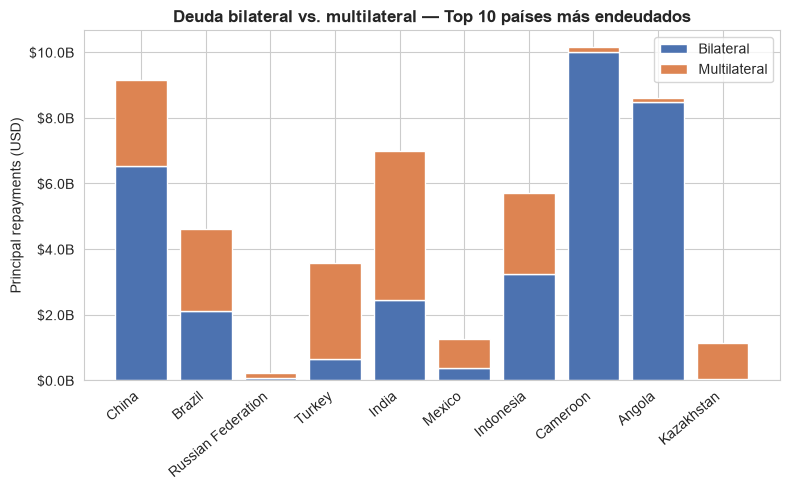

In [13]:
bilat_multi = pd.read_sql('''
    SELECT country_name,
           SUM(CASE WHEN indicator_code = 'DT.AMT.BLAT.CD' THEN debt ELSE 0 END) AS bilateral,
           SUM(CASE WHEN indicator_code = 'DT.AMT.MLAT.CD' THEN debt ELSE 0 END) AS multilateral
    FROM international_debt
    WHERE es_agregado_regional = 0
      AND country_name IN ({})
    GROUP BY country_name
'''.format(",".join(f"'{c}'" for c in top_paises["country_name"])), conn)

bilat_multi = bilat_multi.set_index("country_name").loc[top_paises["country_name"]].reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(bilat_multi))
ax.bar(x, bilat_multi["bilateral"], label="Bilateral", color="#4C72B0")
ax.bar(x, bilat_multi["multilateral"], bottom=bilat_multi["bilateral"], label="Multilateral", color="#DD8452")
ax.set_xticks(list(x))
ax.set_xticklabels(bilat_multi["country_name"], rotation=40, ha="right")
ax.set_ylabel("Principal repayments (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e9:,.1f}B"))
ax.set_title("Deuda bilateral vs. multilateral — Top 10 países más endeudados", fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

**Lectura:** la mezcla bilateral/multilateral varía bastante entre países: algunos dependen
mucho más de acreedores bilaterales (otros gobiernos) mientras que otros tienen una porción
más grande de deuda multilateral (organismos internacionales), lo que puede reflejar
distintas estrategias de financiamiento o distinto acceso a mercados de crédito.

 **Takeaway:** the bilateral/multilateral mix varies quite a bit across countries: some rely
much more heavily on bilateral creditors (other governments), while others have a larger
share of multilateral debt (international institutions) — which may reflect different
financing strategies or different access to credit markets.

### 5.3 Ratio de servicio de deuda: ¿qué países pagan más de lo que reciben? / 5.3 Debt Service Ratio: Which Countries Pay More Than They Receive?

Comparamos lo que un país **paga** (principal + intereses de largo plazo) contra lo que
**recibe** (desembolsos de largo plazo). Un ratio alto sugiere que el país está destinando
una porción importante de sus recursos a pagar deuda vieja en lugar de recibir financiamiento neto nuevo.

🇬🇧 We compare what a country **pays** (long-term principal + interest) against what it
**receives** (long-term disbursements). A high ratio suggests the country is putting a
significant share of its resources toward paying off old debt rather than receiving new net
financing.

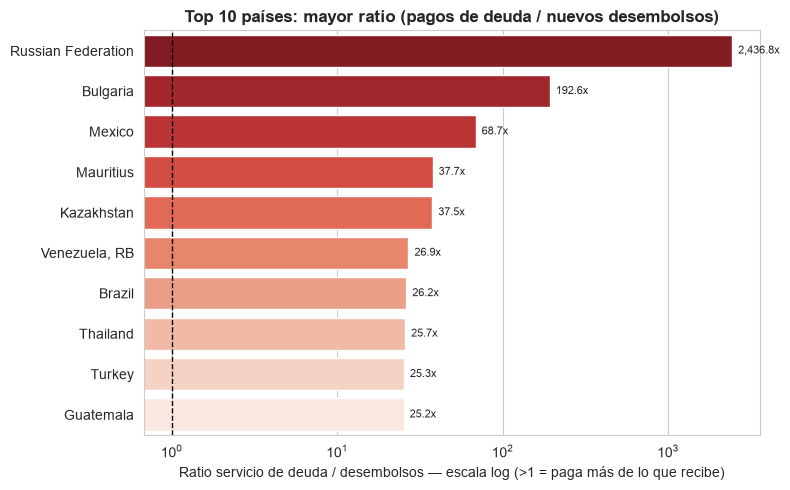

,country_name,principal,intereses,desembolsos,ratio_servicio_desembolso
88,Russian Federation,"66,589,761,834","13,929,825,316","33,043,274","2,437"
15,Bulgaria,"1,883,205,166","1,012,039,083","15,032,935",193
71,Mexico,"25,218,503,927","19,267,966,623","647,628,548",69
70,Mauritius,"1,757,803,962","439,563,478","58,239,434",38
56,Kazakhstan,"27,482,093,686","5,333,500,398","874,231,247",38
115,"Venezuela, RB","9,878,659,207","4,159,342,366","521,048,463",27
14,Brazil,"90,041,840,304","17,001,653,109","4,092,388,651",26
105,Thailand,"5,914,706,998","1,844,227,471","301,616,652",26
110,Turkey,"51,555,031,006","12,095,568,642","2,514,443,147",25
45,Guatemala,"2,911,981,988","563,718,062","137,925,964",25


In [14]:
servicio = pd.read_sql('''
    SELECT country_name,
           SUM(CASE WHEN indicator_code = 'DT.AMT.DLXF.CD' THEN debt ELSE 0 END) AS principal,
           SUM(CASE WHEN indicator_code = 'DT.INT.DLXF.CD' THEN debt ELSE 0 END) AS intereses,
           SUM(CASE WHEN indicator_code = 'DT.DIS.DLXF.CD' THEN debt ELSE 0 END) AS desembolsos
    FROM international_debt
    WHERE es_agregado_regional = 0
    GROUP BY country_name
    HAVING desembolsos > 0
''', conn)

servicio["servicio_total"] = servicio["principal"] + servicio["intereses"]
servicio["ratio_servicio_desembolso"] = servicio["servicio_total"] / servicio["desembolsos"]

top_ratio = servicio.sort_values("ratio_servicio_desembolso", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=top_ratio, y="country_name", x="ratio_servicio_desembolso", hue="country_name", palette="Reds_r", legend=False, ax=ax)
ax.axvline(1, color="black", linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.set_title("Top 10 países: mayor ratio (pagos de deuda / nuevos desembolsos)", fontsize=12, fontweight="bold")
ax.set_xlabel("Ratio servicio de deuda / desembolsos — escala log (>1 = paga más de lo que recibe)")
ax.set_ylabel("")
for i, v in enumerate(top_ratio["ratio_servicio_desembolso"]):
    ax.text(v, i, f"  {v:,.1f}x", va="center", fontsize=8)
plt.tight_layout()
plt.show()

top_ratio[["country_name", "principal", "intereses", "desembolsos", "ratio_servicio_desembolso"]]

**Lectura:** los países con ratio mayor a 1 están, en el período cubierto por el dataset,
pagando más en principal + intereses de lo que reciben en nuevos desembolsos de deuda de
largo plazo — una señal de posible presión de liquidez o de un proceso de desendeudamiento.
El caso de **Rusia** es extremo (ratio ≈ 2,440x, por eso el eje va en escala logarítmica):
pagó cerca de $80B en principal + intereses mientras recibió apenas ~$33M en nuevos
desembolsos de largo plazo, es decir, prácticamente dejó de tomar deuda nueva de este tipo
mientras seguía pagando la anterior.

 **Takeaway:** countries with a ratio above 1 are, over the period covered by the dataset,
paying more in principal + interest than they receive in new long-term debt disbursements —
a possible sign of liquidity pressure or an ongoing deleveraging process. **Russia** is an
extreme case (ratio ≈ 2,440x, which is why the axis uses a log scale): it paid close to $80B
in principal + interest while receiving only ~$33M in new long-term disbursements — in other
words, it essentially stopped taking on new debt of this type while still paying off the old one.

### 5.4 Correlación entre tipos de deuda / 5.4 Correlation Between Debt Types

¿Los países con más deuda bilateral también tienden a tener más deuda multilateral, de bonos, etc.?

🇬🇧 Do countries with more bilateral debt also tend to have more multilateral debt, bond debt, etc.?

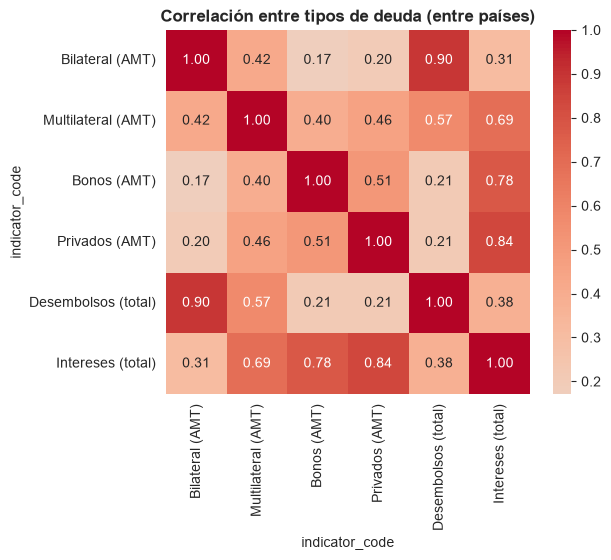

In [15]:
indicadores_clave = {
    "DT.AMT.BLAT.CD": "Bilateral (AMT)",
    "DT.AMT.MLAT.CD": "Multilateral (AMT)",
    "DT.AMT.PRVT.CD": "Privados (AMT)",
    "DT.AMT.PBND.CD": "Bonos (AMT)",
    "DT.INT.DLXF.CD": "Intereses (total)",
    "DT.DIS.DLXF.CD": "Desembolsos (total)",
}

pivot = df[~df["es_agregado_regional"] & df["indicator_code"].isin(indicadores_clave)].pivot_table(
    index="country_name", columns="indicator_code", values="debt", aggfunc="sum"
).rename(columns=indicadores_clave)

corr = pivot.corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax)
ax.set_title("Correlación entre tipos de deuda (entre países)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

**Lectura:** existe una correlación alta entre la mayoría de los tipos de deuda, lo cual es
esperable: los países con economías más grandes simplemente manejan montos más grandes en
todas las categorías. Sería interesante repetir este análisis normalizando por PIB en una
futura iteración (ver sección de próximos pasos).

 **Takeaway:** there's a high correlation between most debt types, which is expected:
countries with larger economies simply handle larger amounts across all categories. It would
be interesting to repeat this analysis normalized by GDP in a future iteration (see the next
steps section).

## 6. Conclusiones / 6. Conclusions

- **China y Brasil** concentran la mayor deuda externa del dataset, seguidos por Rusia, Turquía e India.
- Excluir los **agregados regionales** (South Asia, IDA only, LDC) fue clave para que los rankings
  por país fueran correctos y comparables — este era el principal riesgo de interpretación errónea
  en la versión original del análisis.
- La proporción de deuda **bilateral vs. multilateral** varía significativamente entre los países
  más endeudados, lo que sugiere distintas estrategias/condiciones de financiamiento.
- Algunos países muestran un **ratio de servicio de deuda mayor a 1**, es decir, están pagando más
  de lo que reciben en nuevos desembolsos — una señal a monitorear.
- Los distintos tipos de deuda están, en general, **altamente correlacionados** entre países,
  lo cual refleja principalmente el tamaño económico de cada país.

 **English**

- **China and Brazil** hold the largest external debt in the dataset, followed by Russia, Turkey, and India.
- Excluding **regional aggregates** (South Asia, IDA only, LDC) was key to making the per-country
  rankings correct and comparable — this was the main risk of misinterpretation in the original
  version of the analysis.
- The **bilateral vs. multilateral** debt mix varies significantly among the most indebted
  countries, suggesting different financing strategies/conditions.
- Some countries show a **debt service ratio above 1**, meaning they're paying more than they
  receive in new disbursements — a signal worth monitoring.
- The different debt types are, overall, **highly correlated** across countries, mainly
  reflecting each country's economic size.

## 7. Próximos pasos / 7. Next Steps

- Normalizar la deuda por PIB o por población para comparar "carga real" entre países, no solo montos absolutos.
- Incorporar series de tiempo (si se consigue el dataset con años) para ver evolución, no solo un corte.
- Modelar el ratio de servicio de deuda como indicador de riesgo país.

 **English**

- Normalize debt by GDP or population to compare the "real burden" across countries, not just absolute amounts.
- Incorporate time series (if a dataset with years is available) to see evolution over time, not just a single snapshot.
- Model the debt service ratio as a country-risk indicator.